# Aula 19 — Treinamento e avaliação de um modelo

**Módulo 6 — Introdução ao Machine Learning**
## Objetivos da aula

- Percorrer o fluxo básico de Machine Learning com Scikit-learn: criar, treinar (`fit`) e usar (`predict`) um modelo.
- Avaliar o modelo com métricas de classificação: acurácia, precisão, *recall*, F1-score e matriz de confusão.
- Fechar o curso com um classificador funcional de status de equipamentos — o objetivo que persegue todas as aulas anteriores.

---

## 1. Recriando a base, `X`/`y`, a divisão treino/teste e o escalonamento (Aulas 17 e 18)

In [11]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 500
tipos_equipamento = ["Motor", "Bomba", "Compressor", "Ventilador"]

dados = pd.DataFrame({
    "equipamento_id": [f"EQ-{i:04d}" for i in range(1, n + 1)],
    "tipo_equipamento": np.random.choice(tipos_equipamento, size=n),
    "temperatura": np.round(np.random.normal(70, 12, size=n), 1),
    "pressao": np.round(np.random.normal(5.5, 1.3, size=n), 2),
    "vibracao": np.round(np.random.normal(2.4, 1.1, size=n), 2),
    "horas_operacao": np.random.randint(0, 10000, size=n),
})


def definir_status(linha):
    critico = (linha["temperatura"] >= 90) or (linha["vibracao"] >= 4.5) or (linha["pressao"] >= 8) or (linha["pressao"] <= 2)
    alerta = (linha["temperatura"] >= 80) or (linha["vibracao"] >= 3.5) or (linha["pressao"] >= 7) or (linha["pressao"] <= 3)
    if critico:
        return "critico"
    elif alerta:
        return "alerta"
    else:
        return "normal"


dados["status"] = dados.apply(definir_status, axis=1)
dados.to_csv("sensores_industriais.csv", index=False)

df = pd.read_csv("sensores_industriais.csv")
y = df["status"]

atributos_numericos = ["temperatura", "pressao", "vibracao", "horas_operacao"]
X_numerico = df[atributos_numericos]
tipo_codificado = pd.get_dummies(df["tipo_equipamento"], prefix="tipo", dtype=int)
X = pd.concat([X_numerico, tipo_codificado], axis=1)

print("X:", X.shape, "| y:", y.shape)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y,
)

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[atributos_numericos] = scaler.fit_transform(X_train[atributos_numericos])
X_test_scaled[atributos_numericos] = scaler.transform(X_test[atributos_numericos])

print("Treino:", X_train_scaled.shape, "| Teste:", X_test_scaled.shape)


X: (500, 8) | y: (500,)
Treino: (400, 8) | Teste: (100, 8)


## 2. Escolhendo um modelo: `KNeighborsClassifier`

Vamos usar o **K-Vizinhos Mais Próximos** (*K-Nearest Neighbors*, KNN), um dos algoritmos de classificação mais intuitivos: para classificar um novo equipamento, o modelo olha para os `K` equipamentos **mais parecidos** com ele (mais próximos, considerando todos os atributos) já vistos no treino, e atribui o status **mais comum entre esses vizinhos**.

É exatamente por depender de "distância" entre pontos que o escalonamento da Aula 18 é indispensável aqui: sem ele, `horas_operacao` (números na casa dos milhares) dominaria completamente o cálculo de distância, ofuscando `pressao` e `vibracao` (números pequenos). Na preparação, padronizamos as medidas numéricas e mantivemos as colunas one-hot como indicadores 0/1.


In [12]:
from sklearn.neighbors import KNeighborsClassifier

modelo = KNeighborsClassifier(n_neighbors=5)   # considera os 5 vizinhos mais próximos


## 3. Treinando o modelo: `fit`

O método `.fit(X, y)` é onde o aprendizado de fato acontece: o modelo "memoriza" os atributos e os status correspondentes do conjunto de treino, para poder comparar novos exemplos a eles depois.

In [13]:
modelo.fit(X_train_scaled, y_train)

print("Modelo treinado com", len(X_train_scaled), "exemplos.")


Modelo treinado com 400 exemplos.


## 4. Gerando previsões: `predict`

Agora usamos o modelo treinado para prever o status dos equipamentos do conjunto de **teste** — que ele nunca viu durante o treinamento.

In [14]:
y_previsto = modelo.predict(X_test_scaled)

print("Primeiras 10 previsões: ", list(y_previsto[:10]))
print("Primeiros 10 valores reais:", list(y_test.iloc[:10]))


Primeiras 10 previsões:  ['normal', 'normal', 'alerta', 'normal', 'alerta', 'normal', 'normal', 'alerta', 'normal', 'normal']
Primeiros 10 valores reais: ['normal', 'normal', 'alerta', 'normal', 'critico', 'normal', 'alerta', 'normal', 'alerta', 'normal']


## 5. Avaliando o modelo

Comparamos `y_previsto` (o que o modelo disse) com `y_test` (o que realmente aconteceu) usando métricas do módulo `sklearn.metrics`.

### Acurácia

A métrica mais simples: **proporção de previsões corretas** sobre o total.

In [15]:
from sklearn.metrics import accuracy_score

acuracia = accuracy_score(y_test, y_previsto)
print(f"Acurácia: {acuracia:.1%}")


Acurácia: 71.0%


**Cuidado com a acurácia isolada:** como vimos nas Aulas 17 e 18, as classes são desbalanceadas (muito mais `normal` do que `critico`). Um modelo "preguiçoso" que sempre prevê `normal` já acertaria uma fração alta das vezes, sem realmente aprender nada útil sobre os casos críticos — justamente os mais importantes de detectar. Por isso, olhamos também precisão, *recall* e F1-score, calculados **por classe**.

### Precisão, *recall* e F1-score

- **Precisão**: das vezes que o modelo previu uma classe (ex.: `critico`), quantas realmente eram daquela classe? (mede *falsos positivos*)
- ***Recall*** (sensibilidade): dos casos que realmente eram de uma classe, quantos o modelo conseguiu identificar? (mede *falsos negativos* — em um cenário industrial, deixar de detectar um `critico` real costuma ser o erro mais caro)
- **F1-score**: uma média que equilibra precisão e *recall* em um único número.

Como temos três classes (não apenas duas), usamos `average="macro"`, que calcula a métrica para cada classe separadamente e depois tira a média simples entre elas — tratando as três classes com a mesma importância, independentemente de quantos exemplos cada uma tem.

Usamos ainda `zero_division=0`: quando o modelo não prevê **nenhum** exemplo de uma classe, a precisão dessa classe seria uma divisão por zero (indefinida). Esse parâmetro instrui o Scikit-learn a tratar esse caso como `0`, em vez de emitir o aviso `UndefinedMetricWarning`.

In [16]:
from sklearn.metrics import precision_score, recall_score, f1_score

ordem_classes = ["normal", "alerta", "critico"]

precisao = precision_score(y_test, y_previsto, average="macro", zero_division=0)
recall = recall_score(y_test, y_previsto, average="macro", zero_division=0)
f1 = f1_score(y_test, y_previsto, average="macro", zero_division=0)

print(f"Precisão (macro): {precisao:.1%}")
print(f"Recall (macro):   {recall:.1%}")
print(f"F1-score (macro): {f1:.1%}")


Precisão (macro): 44.5%
Recall (macro):   50.3%
F1-score (macro): 47.2%


### Relatório completo por classe

`classification_report` calcula precisão, *recall* e F1-score **para cada classe individualmente** — essencial para verificar se o modelo está falhando especificamente na classe `critico`, que é a mais importante e também a mais rara.

In [17]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_previsto, labels=ordem_classes, zero_division=0))


              precision    recall  f1-score   support

      normal       0.79      0.95      0.86        56
      alerta       0.55      0.56      0.55        32
     critico       0.00      0.00      0.00        12

    accuracy                           0.71       100
   macro avg       0.45      0.50      0.47       100
weighted avg       0.62      0.71      0.66       100



### Matriz de confusão

A **matriz de confusão** mostra, para cada classe real (linhas), quantas vezes o modelo previu cada classe possível (colunas) — revelando exatamente **onde** o modelo erra, e não apenas quanto erra.

In [18]:
from sklearn.metrics import confusion_matrix

matriz = confusion_matrix(y_test, y_previsto, labels=ordem_classes)

print("Ordem das classes:", ordem_classes)
print(matriz)


Ordem das classes: ['normal', 'alerta', 'critico']
[[53  3  0]
 [14 18  0]
 [ 0 12  0]]


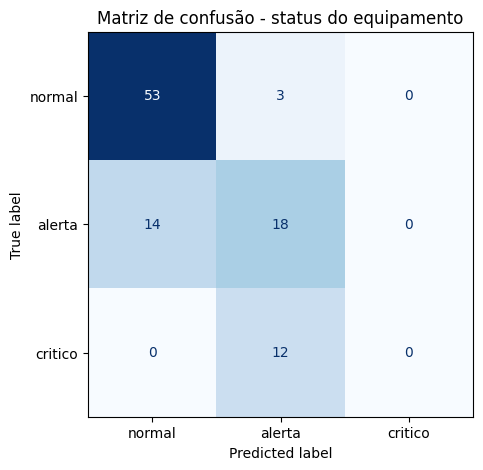

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

%matplotlib inline

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=ordem_classes).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Matriz de confusão - status do equipamento")
plt.show()


**Como ler a matriz de confusão:** a diagonal principal (de cima à esquerda até embaixo à direita) mostra os acertos — quanto mais concentrados os valores estiverem nela, melhor. Valores fora da diagonal são erros: por exemplo, a célula na linha `critico` e coluna `normal` mostra quantos equipamentos realmente críticos o modelo classificou (erradamente) como normais — o tipo de erro mais perigoso em um cenário real de monitoramento industrial.

## 6. Encerramento do curso

Ao longo destas 19 aulas, percorremos o caminho completo de uma análise de dados industrial com Python: começamos aprendendo a sintaxe básica da linguagem no Google Colab (Módulos 1 e 2), passamos pela computação numérica eficiente com NumPy (Módulo 3), pela organização e limpeza de dados tabulares com Pandas (Módulo 4), pela comunicação visual dos resultados com Matplotlib (Módulo 5) e chegamos, nesta última aula, a um **modelo de Machine Learning funcional**, capaz de classificar automaticamente o estado de um equipamento a partir das leituras de seus sensores.

Essa é exatamente a base de conhecimento prática cobrada nas avaliações do OPAIOT — e, mais importante, a base para qualquer análise de dados real no dia a dia de operação de processos industriais.

## 7. Resumo da aula

- O fluxo básico do Scikit-learn é sempre: criar o modelo → `fit(X_train, y_train)` → `predict(X_test)` → avaliar.
- Acurácia mede o acerto geral, mas pode enganar em bases desbalanceadas.
- Precisão, *recall* e F1-score (com `average="macro"` para múltiplas classes) avaliam o desempenho por classe.
- A matriz de confusão revela exatamente onde e como o modelo erra.

### Exercício sugerido

Treine um novo modelo `KNeighborsClassifier(n_neighbors=3)` (em vez de 5) com os mesmos dados de treino, gere as previsões no mesmo conjunto de teste e compare a acurácia e o F1-score macro com o modelo original. O número de vizinhos `K` faz diferença no desempenho?
